## 1. Carga de librerías y dataset

Se importan las librerías clave para el análisis y se carga el dataset desde `data/train.csv` usando **pathlib.Path**. Se valida la carga comprobando la dimensión del DataFrame.

### ¿Por qué?
`pathlib.Path` construye rutas relativas de forma robusta en Windows, evitando errores por separadores de directorio. Validar dimensiones al inicio garantiza que la fuente de datos está completa antes de cualquier transformación.

### Insights
- El dataset contiene **1,460 transacciones inmobiliarias reales** de Ames, Iowa, con **81 atributos por propiedad**.
- El volumen es suficiente para construir un modelo de tasación con utilidad práctica en decisiones de **compra**, **venta** y **valoración** residencial.

In [ ]:
import pandas as pd          # Manipulación y análisis tabular de datos
import numpy as np           # Operaciones numéricas y transformaciones matemáticas
import matplotlib.pyplot as plt  # Visualizaciones base: histogramas, boxplots, subplots
import seaborn as sns        # Visualizaciones estadísticas de alto nivel: heatmaps, boxplots
from pathlib import Path     # Manejo de rutas de archivo multiplataforma
from scipy import stats      # Pruebas estadísticas: ANOVA, normalidad, Q-Q plot

In [3]:
data_path = Path("../../data/train.csv")
df = pd.read_csv(data_path)
print(df)

        Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0        1          60       RL         65.0     8450   Pave   NaN      Reg   
1        2          20       RL         80.0     9600   Pave   NaN      Reg   
2        3          60       RL         68.0    11250   Pave   NaN      IR1   
3        4          70       RL         60.0     9550   Pave   NaN      IR1   
4        5          60       RL         84.0    14260   Pave   NaN      IR1   
...    ...         ...      ...          ...      ...    ...   ...      ...   
1455  1456          60       RL         62.0     7917   Pave   NaN      Reg   
1456  1457          20       RL         85.0    13175   Pave   NaN      Reg   
1457  1458          70       RL         66.0     9042   Pave   NaN      Reg   
1458  1459          20       RL         68.0     9717   Pave   NaN      Reg   
1459  1460          20       RL         75.0     9937   Pave   NaN      Reg   

     LandContour Utilities  ... PoolArea PoolQC  Fe

In [10]:
print(f'Filas: {df.shape[0]}')
print(f'Columnas: {df.shape[1]}')

Filas: 1460
Columnas: 81


## 2. Inspección inicial de estructura y variable objetivo

Se revisa el DataFrame con `head()`, `info()` y `describe()` sobre **SalePrice** para detectar problemas tempranos: tipos de dato incorrectos, nulos inesperados o rangos fuera de lo razonable.

### ¿Por qué?
Una variable numérica cargada como `object` falla silenciosamente en los cálculos estadísticos posteriores. Conocer el perfil de **SalePrice** desde el inicio orienta todas las decisiones de modelado: si el precio tiene sesgo, el modelo debe tratarlo antes de entrenar.

### Insights
- **Media de 180,921 USD** vs. **mediana de 163,000 USD** — la brecha de ~18,000 USD indica propiedades de alto valor que empujan el promedio hacia arriba.
- Usar la media como referencia de mercado **sobreestimaría el valor típico** en aproximadamente 18,000 USD respecto al precio real del hogar mediano.
- La distribución asimétrica detectada aquí se confirma y trata en los bloques 4, 5 y 6.

In [23]:
# Muestra las primeras 5 filas del dataset
# Permite ver la estructura real de los datos
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [12]:
# Información estructural del DataFrame
# Muestra: nombre de columna, cantidad de non-null values y dtype
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## 3. Diagnóstico de valores faltantes

Se cuantifican y ordenan las columnas con nulos para priorizar el tratamiento antes del modelado.

### ¿Por qué?
Ignorar los nulos descarta filas útiles; imputarlos mal introduce sesgo. En datos inmobiliarios, muchos nulos no son pérdidas de información sino **ausencias reales de características** — codificarlos incorrectamente como vacíos distorsionaría las relaciones con el precio.

### Insights
- **19 columnas** presentan valores faltantes.
- **`PoolQC` (1,453)**, **`MiscFeature` (1,406)** y **`Alley` (1,369)** tienen nulos porque la mayoría de propiedades no poseen piscina, elemento misceláneo ni callejón — **la ausencia es el dato**.
- La estrategia correcta es **codificar la ausencia como categoría válida** (`"None"`) en lugar de eliminar registros o imputar con moda.

In [16]:
# Cuenta los nulos por columna y filtra solo las que tienen al menos 1
# .isnull() retorna True/False por cada celda
# .sum() suma los True (los nulos)
# sort_values ordena de mayor a menor para ver los más críticos primero
nulos = df.isnull().sum()
nulos[nulos > 0].sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [13]:
# Estadística descriptiva de variables numéricas
# count, mean, std, min, percentiles, max
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


> **Hipótesis:** La diferencia positiva entre media y mediana de **SalePrice** se debe a propiedades de alto valor que sesgan el promedio. La mayoría de las transacciones ocurren en un rango menor, lo que produce una **distribución asimétrica hacia la derecha** — patrón típico en mercados inmobiliarios donde el segmento premium es minoritario pero desproporcionadamente influyente en la media. Esta hipótesis se valida visualmente en el bloque 4.

In [17]:
# Accede a una columna específica y aplica describe()
# Los corchetes seleccionan la columna como una Serie
df['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

## 4. Distribución y outliers de SalePrice

Se visualiza **SalePrice** con histograma y boxplot para entender concentración, dispersión y valores extremos.

### ¿Por qué?
Antes de modelar, es necesario conocer la forma real de la distribución del precio. Si hay cola derecha marcada, un modelo lineal sin transformación subestimará sistemáticamente las propiedades premium. El boxplot complementa al histograma: donde uno muestra forma, el otro expone outliers de forma precisa.

### Insights
- Mayor densidad de transacciones entre **100,000 y 200,000 USD** — segmento masivo del mercado de Ames.
- El **50% de las transacciones** se concentra entre **129,975 y 214,000 USD** (IQR).
- Los **outliers superiores** (propiedades premium) deben **conservarse** — representan el segmento de alto ticket, relevante para estrategias de inversión y valuación de activos.

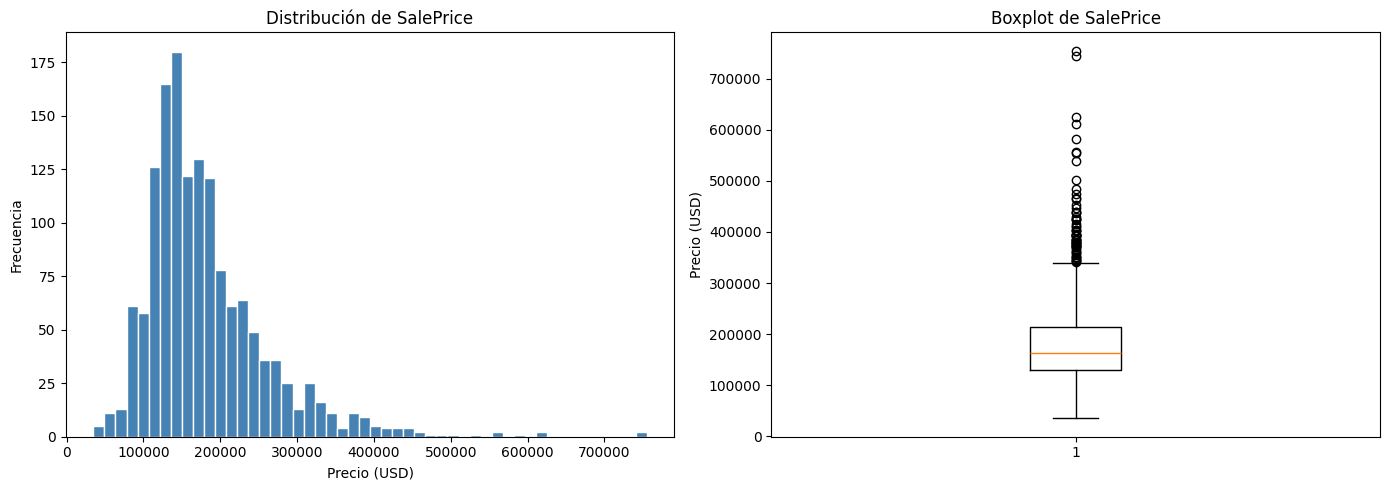

In [16]:
# Figura con dos subplots lado a lado
# Crea un lienzo plt.subplots(filas,columnas, figsize=(ancho,alto))
# El resultado es fig (lienzo completo) y axes (arreglo con los dos espacios)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Histograma de SalePrice ---
# Para este grafico se selecciona el primer espacio dentro del arreglo axes
# bins=50 divide el rango en 50 barras para ver la forma real, color= Color de las barras
# edgecolor= Color del borde las barras
axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white')
# Estos 3 parametros se usaran practicamente en cada grafico
axes[0].set_title('Distribución de SalePrice')
axes[0].set_xlabel('Precio (USD)')
axes[0].set_ylabel('Frecuencia')

# --- Boxplot de SalePrice ---
# Para este grafico se selecciona el segundo espacio dentro del arreglo axes
# Muestra mediana, cuartiles y outliers visualmente
axes[1].boxplot(df['SalePrice'], vert=True)
axes[1].set_title('Boxplot de SalePrice')
axes[1].set_ylabel('Precio (USD)')

plt.tight_layout()  # Ajusta espacios automáticamente para que no se encimen
plt.show()          # Renderiza y muestra el gráfico

## 5. Validación de normalidad de SalePrice

Se evalúa si **SalePrice** cumple el supuesto de normalidad mediante histograma con curva KDE y Q-Q Plot.

### ¿Por qué?
La regresión lineal estándar asume que los residuos siguen una distribución normal. Si la variable objetivo tiene sesgo pronunciado, las predicciones en el rango premium serán sistemáticamente incorrectas. Confirmar la falta de normalidad justifica formalmente la transformación logarítmica del bloque siguiente.

### Insights
- El **KDE muestra una cola derecha marcada** — **SalePrice no sigue distribución normal**.
- El **Q-Q Plot** confirma desviaciones en la cola superior respecto a la normal teórica: los puntos se separan de la línea diagonal en los valores más altos.
- Sin corrección, el modelo lineal **subestimaría propiedades premium**, elevando el riesgo en decisiones de crédito e inversión donde los errores en el extremo superior tienen mayor impacto económico.

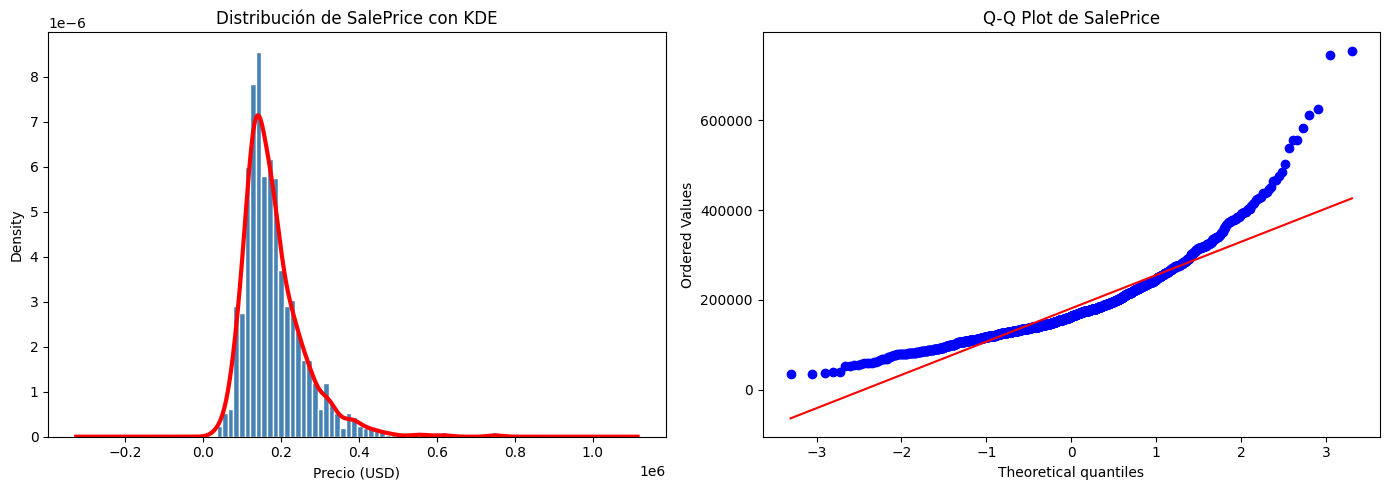

In [22]:
#Nuevamente se genera una grafica con dos lienzos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma con dos capas:
# density=True normaliza el eje Y para que sea compatible con la curva KDE
# kind='hist' dibuja las barras
df['SalePrice'].plot(kind='hist', bins=50, density=True,
                     ax=axes[0], color='steelblue', edgecolor='white')

# kind='kde' superpone la curva de densidad estimada sobre el histograma
df['SalePrice'].plot(kind='kde', ax=axes[0], color='red', linewidth=3)
axes[0].set_title('Distribución de SalePrice con KDE')
axes[0].set_xlabel('Precio (USD)')

# Q-Q Plot: compara tu distribución contra una normal teórica
# Si los puntos siguen la línea — distribución normal
# Si se desvían en los extremos — hay sesgo
stats.probplot(df['SalePrice'], plot=axes[1])
axes[1].set_title('Q-Q Plot de SalePrice')

plt.tight_layout()
plt.show()

## 6. Transformación logarítmica del precio

Se aplica `np.log()` a **SalePrice** creando la columna **SalePrice_log**, y se compara visualmente la distribución original con la transformada.

### ¿Por qué?
El mercado inmobiliario opera en términos relativos: un incremento del 10% en una propiedad de 100,000 USD y en una de 500,000 USD son eventos equivalentes en proporción pero muy distintos en términos absolutos. La escala logarítmica captura esta dinámica y comprime la cola derecha, acercando la distribución a una forma simétrica compatible con regresión lineal.

### Insights
- La transformación **comprime la cola derecha** y produce una distribución visualmente más cercana a una campana.
- El modelo se entrenará sobre **SalePrice_log**; para obtener predicciones en USD se aplica la inversa `np.exp()`.
- Esta transformación es estándar en datasets inmobiliarios y financieros con sesgo positivo — reduce el peso desproporcionado de las propiedades premium en la función de pérdida.

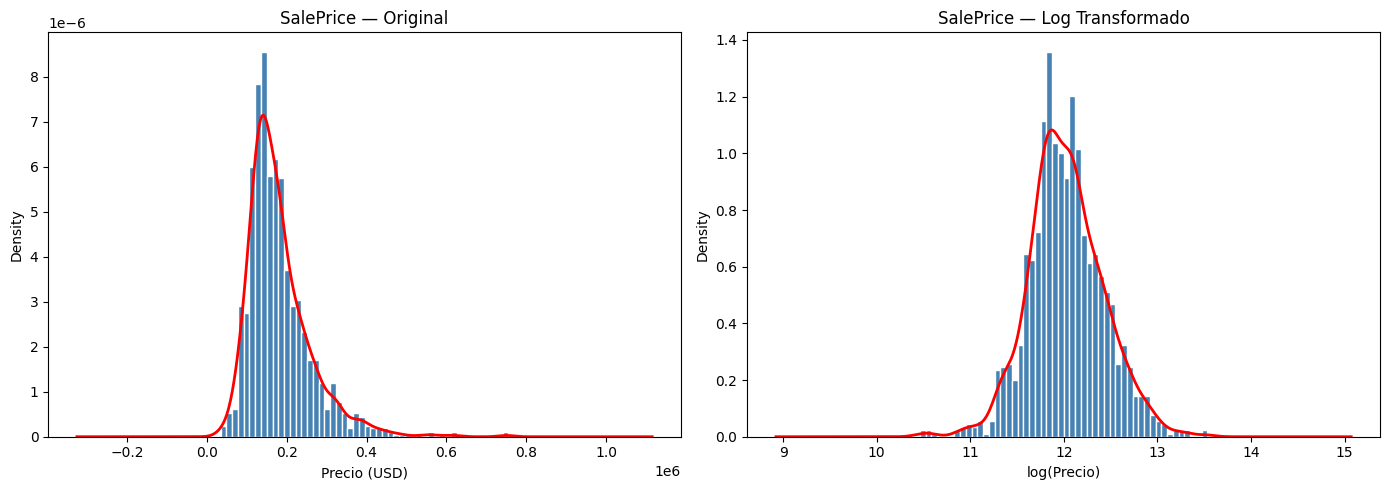

In [23]:
# Aplicamos logaritmo natural a SalePrice
# np.log() es logaritmo natural — comprime valores extremos
df['SalePrice_log'] = np.log(df['SalePrice'])

# Comparamos distribución original vs transformada
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución original
df['SalePrice'].plot(kind='hist', bins=50, density=True,
                    ax=axes[0], color='steelblue', edgecolor='white')
df['SalePrice'].plot(kind='kde', ax=axes[0], color='red', linewidth=2)
axes[0].set_title('SalePrice — Original')
axes[0].set_xlabel('Precio (USD)')

# Distribución transformada
df['SalePrice_log'].plot(kind='hist', bins=50, density=True,
                         ax=axes[1], color='steelblue', edgecolor='white')
df['SalePrice_log'].plot(kind='kde', ax=axes[1], color='red', linewidth=2)
axes[1].set_title('SalePrice — Log Transformado')
axes[1].set_xlabel('log(Precio)')

plt.tight_layout()
plt.show()

## 7. Correlaciones clave con SalePrice

Se calcula la **correlación de Pearson** entre todas las variables numéricas y **SalePrice**, ordenada por valor absoluto para priorizar los predictores de mayor impacto.

### ¿Por qué?
Cuantificar la correlación lineal antes de modelar permite seleccionar variables candidatas, reducir dimensionalidad y eliminar ruido. El valor absoluto garantiza que relaciones negativas fuertes no sean ignoradas en el ordenamiento.

### Insights
- **`OverallQual` (r = 0.79)** es el predictor numérico más fuerte — la calidad percibida domina el mercado de Ames por encima de cualquier atributo físico.
- **`GrLivArea` (r = 0.71)** y **`GarageArea` (r = 0.62)** confirman que metros cuadrados habitables y capacidad de garaje son impulsores materiales del precio.
- **`YearBuilt` (r = 0.52)** demuestra que la antigüedad de la propiedad tiene impacto significativo y no puede descartarse del modelo.
- Variables con `r < 0.10` como `MoSold`, `YrSold` e `Id` no aportan señal útil y son candidatas a eliminación.

In [30]:
# Seleccionamos solo columnas numéricas del DataFrame
# select_dtypes filtra por tipo de dato
numericas = df.select_dtypes(include=[np.number])

# Calculamos correlación de Pearson entre todas las variables numéricas
# .corr() retorna una matriz de NxN donde N = número de columnas numéricas
correlacion = numericas.corr()

# Extraemos solo la correlación contra SalePrice y ordenamos de mayor a menor
# abs() toma el valor absoluto — correlaciones negativas también importan
correlacion_target = correlacion['SalePrice'].abs().sort_values(ascending=False)

# Mostramos las 15 variables más correlacionadas con SalePrice
print(correlacion_target)

SalePrice        1.000000
SalePrice_log    0.948374
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
KitchenAbvGr     0.135907
EnclosedPorch    0.128578
ScreenPorch      0.111447
PoolArea         0.092404
MSSubClass       0.084284
OverallCond      0.077856
MoSold           0.046432
3SsnPorch        0.044584
YrSold           0.028923
LowQualFinSF     0.025606
Id               0.021917
MiscVal          0.021190
BsmtHalfBath     0.016844
BsmtFinSF2  

## 8. Matriz de correlación y control de multicolinealidad

Se construye una matriz de correlación entre las variables numéricas top para detectar redundancia entre predictores antes de entrenar el modelo.

### ¿Por qué?
La multicolinealidad no reduce la capacidad predictiva del modelo, pero sí su **interpretabilidad** y la **estabilidad de los coeficientes**. Si dos variables están altamente correlacionadas entre sí, incluir ambas no agrega información real y puede inflar la varianza de los estimadores, dificultando la lectura del peso real de cada predictor.

### Insights
- **`GarageCars` y `GarageArea`** (r ≈ 0.88) son altamente redundantes — se conserva **`GarageArea`** por ser continua y más granular.
- **`GrLivArea` y `TotRmsAbvGrd`** muestran alta correlación — se conserva **`GrLivArea`** por su correlación directa con el precio.
- **`YearBuilt` y `GarageYrBlt`** son redundantes — se conserva **`YearBuilt`** como indicador principal de antigüedad del inmueble.
- La depuración de variables correlacionadas mejora la **estabilidad e interpretabilidad** del modelo sin sacrificar capacidad predictiva.

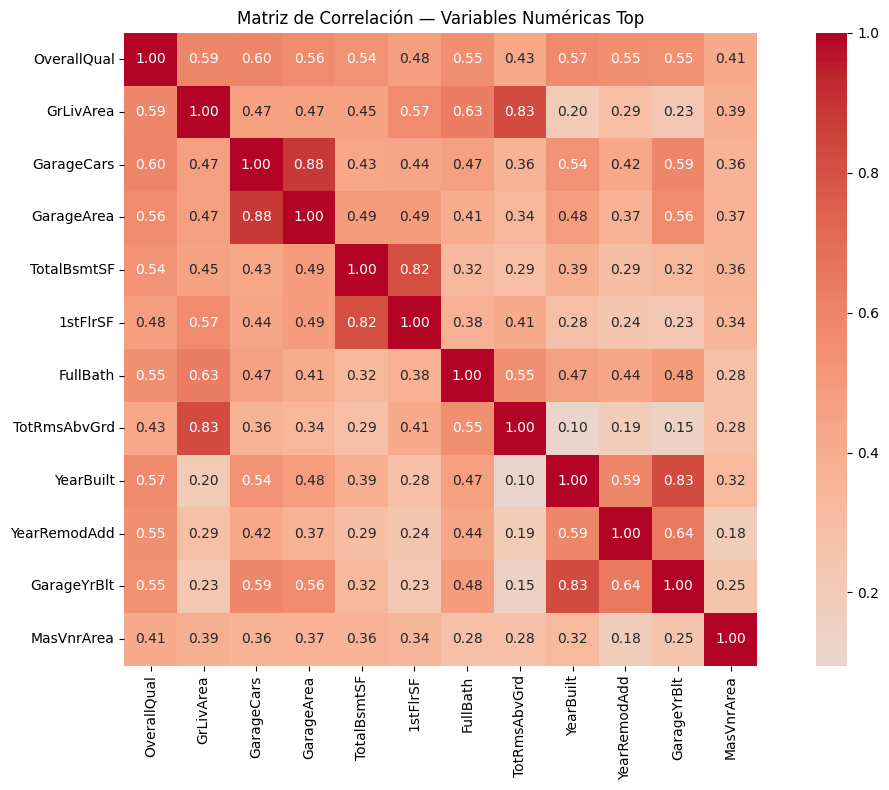

In [25]:
# Seleccionamos las 15 variables más correlacionadas con SalePrice
# Excluimos SalePrice_log porque es derivada directa del target
top_vars = correlacion_target.drop(['SalePrice', 'SalePrice_log']).head(12).index

# Calculamos correlación entre esas variables — no contra el target
# sino entre ellas mismas
corr_matrix = numericas[top_vars].corr()

# Visualizamos con heatmap
plt.figure(figsize=(12, 8))

# annot=True muestra los valores numéricos dentro de cada celda
# fmt='.2f' formatea a 2 decimales
# cmap define la paleta de colores — rojo alto, azul bajo
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True)

plt.title('Matriz de Correlación — Variables Numéricas Top')
plt.tight_layout()
plt.show()

## 9. ANOVA sobre variables categóricas

**Qué se hace:** Se aplica ANOVA sobre las 43 variables categóricas del dataset para medir estadísticamente cuánto diferencia el precio de venta cada una.

**Por qué:** La correlación de Pearson solo funciona con variables numéricas. El ANOVA es el equivalente estadístico para categóricas — el F-Statistic mide la separación de medias entre grupos y el P-Value confirma si esa separación es real o producto del azar. Sin esta prueba, incluir variables categóricas irrelevantes inflaría el modelo con ruido y aumentaría el costo computacional del encoding.

**Insights:**
- **`ExterQual` (F=443)**, **`KitchenQual` (F=408)** y **`BsmtQual` (F=393)** son las variables categóricas con mayor impacto en el precio; superan incluso a variables numéricas como `GarageArea`.
- Se descartaron 5 variables con P-Value > 0.05 (`Street`, `MiscFeature`, `LandSlope`, `PoolQC`, `Utilities`) por no tener relación estadísticamente significativa con el precio.
- Variables con F-Statistic < 10 se descartaron por bajo impacto predictivo y alto costo de encoding en el modelo final.

In [28]:
# Lista de variables categóricas de calidad a evaluar
vars_categoricas_todas = df.select_dtypes(include=['object']).columns.tolist()
print(f'Total variables categóricas: {len(vars_categoricas_todas)}')
print(vars_categoricas_todas)

# Para cada variable calculamos el F-statistic del ANOVA
# F alto y p-value bajo significa que la variable SÍ diferencia precios significativamente
resultados = []

for var in vars_categoricas_todas:
    # Eliminamos nulos para esa variable
    df_temp = df[['SalePrice', var]].dropna()
    
    # Agrupamos SalePrice por cada categoría de la variable
    grupos = [grupo['SalePrice'].values 
              for _, grupo in df_temp.groupby(var)]
    
    # ANOVA de un factor
    f_stat, p_value = stats.f_oneway(*grupos)
    
    resultados.append({
        'Variable': var,
        'F-Statistic': round(f_stat, 2),
        'P-Value': round(p_value, 6)
    })

# Convertimos a DataFrame y ordenamos por F-Statistic
resultados_df = pd.DataFrame(resultados).sort_values('F-Statistic', ascending=False)
# print(resultados_df.head(10))
print(resultados_df)

Total variables categóricas: 43
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
         Variable  F-Statistic   P-Value
18      ExterQual       443.33  0.000000
30    KitchenQual       407.81  0.000000
21       BsmtQual       392.91  0.000000
34   GarageFinish       250.96  0.000000
20     Foundation       100.25  0.000000
28     CentralAir        98.31  0.000000
27      HeatingQC        88.39  0.000000
8    Neighborhood        71.78  0.000000
33     GarageType  

## 10. Visualización de variables de calidad

**Qué se hace:** Se genera una grilla 2×4 con boxplots de precios e histogramas de frecuencia para `OverallQual`, `ExterQual`, `KitchenQual` y `BsmtQual`.

**Por qué:** El boxplot muestra la variación de precios por categoría, pero no revela cuántas propiedades hay en cada segmento. Si una categoría tiene muy pocos registros, la dispersión del boxplot puede ser engañosa. Combinar ambas visualizaciones permite distinguir si la variabilidad de precio responde al mercado real o simplemente a escasez de datos, lo cual es crítico para evaluar la confiabilidad del modelo en esos segmentos.

**Insights:**
- **`OverallQual`** confirma una relación escalonada precio-calidad; el mercado se concentra en los niveles **5 a 7**, perfil típico de una ciudad universitaria de clase media como Ames, Iowa.
- **`ExterQual`** y **`KitchenQual`** muestran que más del 90% de las propiedades están en categorías TA y Gd — el modelo tendrá menor precisión en los extremos (Po, Fa, Ex) por sesgo de representación.
- **Cocinas Ex (Excellent)** se asocian exclusivamente con propiedades premium por encima de **300,000 USD**.
- **`BsmtQual`** no registra ninguna propiedad en nivel Po (Poor) — los sótanos en Ames tienen un estándar mínimo de construcción exigido por el clima extremo del Midwest americano.

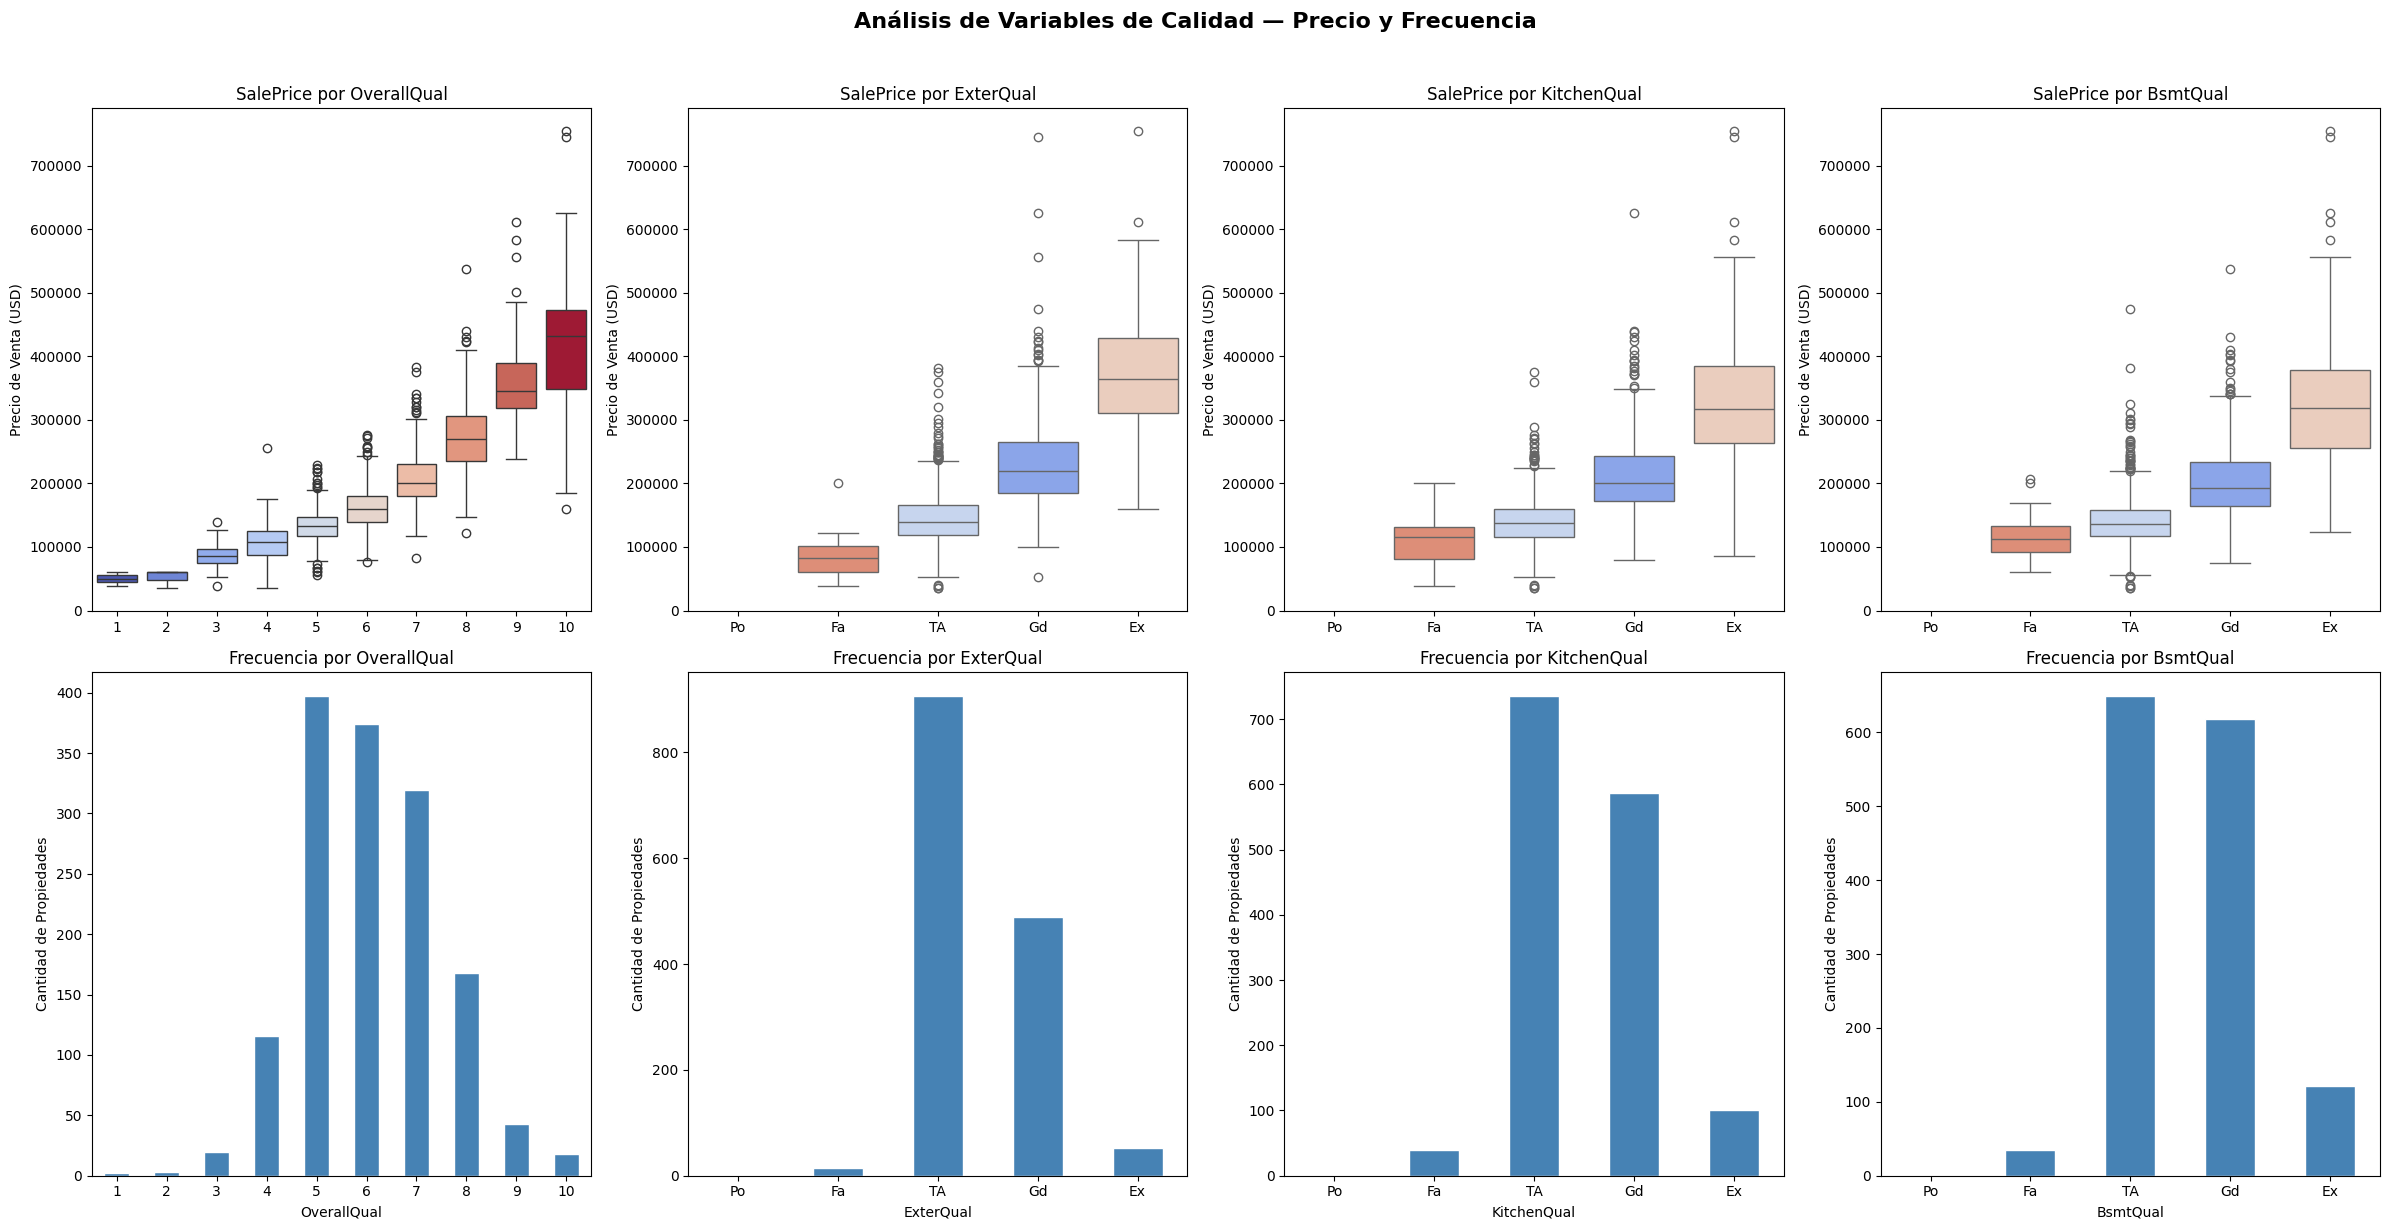

In [35]:
# 4 variables con sus órdenes jerárquicos correctos
variables_orden = {
    'OverallQual': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'ExterQual':   ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'KitchenQual': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'BsmtQual':    ['Po', 'Fa', 'TA', 'Gd', 'Ex']
}

# 2 filas — fila 0: boxplots / fila 1: histogramas de frecuencia
# 4 columnas — una por variable
fig, axes = plt.subplots(2, 4, figsize=(24, 12))

for col, (var, orden) in enumerate(variables_orden.items()):

    # --- Fila 0: Boxplot — distribución de precios por categoría ---
    sns.boxplot(x=var, y='SalePrice', data=df,
                order=orden,
                hue=var, palette='coolwarm',
                legend=False, ax=axes[0, col])
    axes[0, col].set_title(f'SalePrice por {var}')
    axes[0, col].set_xlabel('')
    axes[0, col].set_ylabel('Precio de Venta (USD)')

    # --- Fila 1: Histograma — frecuencia de propiedades por categoría ---
    # value_counts() cuenta propiedades por categoría
    # reindex() garantiza que el orden del eje X sea el correcto
    conteo = df[var].value_counts().reindex(orden)
    conteo.plot(kind='bar', ax=axes[1, col],
                color='steelblue', edgecolor='white')
    axes[1, col].set_title(f'Frecuencia por {var}')
    axes[1, col].set_xlabel(var)
    axes[1, col].set_ylabel('Cantidad de Propiedades')
    axes[1, col].tick_params(axis='x', rotation=0)

plt.suptitle('Análisis de Variables de Calidad — Precio y Frecuencia',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()